In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fitting_func_lite import *

In [2]:
example = np.load('example_spectrum.npz')
z       = 0 # this is used for resolution calculation
lam     = example['lam'] # rest frame wavelength
flux    = example['flux'] # flux (coadded - continuum)
ivar    = example['ivar'] # inverse variance
mask    = example['mask'] # mask

In [3]:
lines_to_fit = {
    'OII'       : ([OII_rest[0]-20, OII_rest[1]+20], [(OII_rest[0], OII_rest[1])], 1/1.33),  # fixed ratio for [OII]3727/3729
    'Hbeta'     : ([Hbeta_rest[0]-20, Hbeta_rest[0]+20], [Hbeta_rest[0]], 0),
    'OIII'      : ([OIII_rest[0]-20, OIII_rest[1]+20], [(OIII_rest[0], OIII_rest[1])], 1/3.00),  # fixed ratio for [OIII]4959/5007
    'Halpha'    : ([NII_rest[0]-20, NII_rest[1]+20], [(NII_rest[0], NII_rest[1]), Halpha_rest[0]], 1/3.05), # fixed ratio for [NII]
    'SII'       : ([SII_rest[0]-20, SII_rest[1]+20], [SII_rest[0], SII_rest[1]], 0)
}
# ([line_range], [line_centers], line_ratio)
# if doublet, use tuple in line_centers and give line_ratios

In [4]:
params_1comp, _, slice_indices, n_lines_fit = fit_multi_emission(
    lam, flux, ivar, mask, z, lines_to_fit, two_component=False
)
model_1comp = np.sum([
    model_vel(lam, gaussian_parms=params_1comp['gaussian_params'][i]) for i in range(len(slice_indices)+1)
], axis=0)

In [5]:
params_2comp, _, slice_indices, n_lines_fit = fit_multi_emission(
    lam, flux, ivar, mask, z, lines_to_fit, two_component=True
)
model_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['gaussian_params'][i]) for i in range(len(slice_indices)+1)
], axis=0)

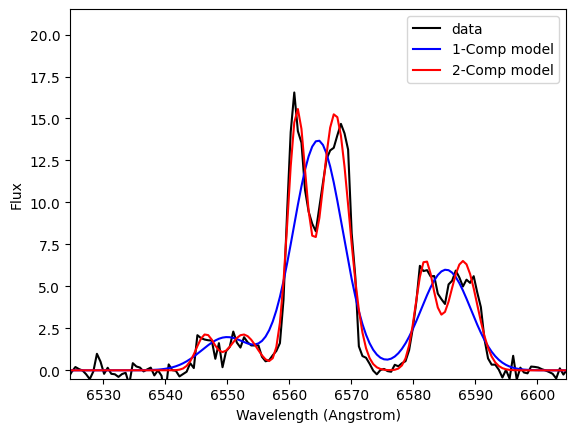

In [6]:
plt.plot(lam, flux, label='data', color='black')
plt.plot(lam, model_1comp, label='1-Comp model', color='blue')
plt.plot(lam, model_2comp, label='2-Comp model', color='red')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.xlim([Halpha_rest[0]-40, Halpha_rest[0]+40])
plt.ylim([-0.5, np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.3])
plt.legend()
plt.show()